# Conflict-resolution behavior: thinking vs. non-thinking

This notebook scans the per-sample behavior-evaluation JSON files and compares thinking with non-thinking generations. It automatically includes newly completed models (including `google/gemma-4-12B-it`) whenever the notebook is rerun.

Behavior labels:

- **1**: directly answers without acknowledging the conflict
- **2**: identifies the conflict, does not answer, and asks for clarification
- **3**: identifies the conflict, resolves it, and answers
- **4**: other behavior

The notebook reports both all currently evaluated rows and strict paired comparisons. Paired comparisons only use the same `(model, conflict_type, sample_id)` when both thinking modes are available.

In [9]:
from pathlib import Path
import json
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "evaluation_outputs").exists():
    if (REPO_ROOT.parent / "evaluation_outputs").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise FileNotFoundError("Run this notebook from the repository root or analysis/ directory.")

JUDGE_MODEL = "gpt-4o-2024-11-20"
EVAL_ROOT = (
    REPO_ROOT
    / "evaluation_outputs"
    / "constraint_triplets"
    / f"judge_{JUDGE_MODEL}"
    / "conflict_resolution_behavior"
)
FIGURE_DIR = REPO_ROOT / "analysis" / "behavior_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {
    1: "Direct answer",
    2: "Ask clarification",
    3: "Self-resolve + answer",
    4: "Other",
    -1: "Invalid judge output",
}
MODE_ORDER = ["non_thinking", "thinking"]
MODE_LABELS = {"non_thinking": "Non-thinking", "thinking": "Thinking"}

print("Repository:", REPO_ROOT)
print("Evaluation root:", EVAL_ROOT)
print("Figure output:", FIGURE_DIR)

Repository: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/ConInstruct-master
Evaluation root: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/ConInstruct-master/evaluation_outputs/constraint_triplets/judge_gpt-4o-2024-11-20/conflict_resolution_behavior
Figure output: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/ConInstruct-master/analysis/behavior_figures


In [10]:
def load_behavior_rows(eval_root):
    rows = []
    for path in sorted(eval_root.rglob("*.json")):
        if path.name == "results.json":
            continue
        with path.open("r", encoding="utf-8") as handle:
            record = json.load(handle)
        if record.get("evaluation_task") != "conflict_resolution_behavior":
            continue
        rows.append({
            "path": str(path),
            "model": record["model"],
            "mode": "thinking" if record["enable_thinking"] else "non_thinking",
            "condition": record["condition"],
            "conflict_type_idx": int(record["conflict_type_idx"]),
            "sample_id": int(record["sample_id"]),
            "status": record.get("evaluation_status", "legacy"),
            "label": record.get("label"),
            "label_name": record.get("label_name"),
            "extraction_error": record.get("response_extraction_error"),
        })
    return pd.DataFrame(rows)

raw_df = load_behavior_rows(EVAL_ROOT)
if raw_df.empty:
    raise ValueError(f"No behavior evaluation files found under {EVAL_ROOT}")

evaluated_df = raw_df.loc[raw_df["status"].eq("evaluated")].copy()
evaluated_df["label"] = evaluated_df["label"].astype(int)
evaluated_df["label_display"] = evaluated_df["label"].map(LABEL_NAMES)

print(f"Files found: {len(raw_df):,}")
print(f"Successfully evaluated: {len(evaluated_df):,}")
display(
    raw_df.groupby(["model", "mode", "status"], observed=True)
    .size().rename("count").reset_index()
)

Files found: 3,169
Successfully evaluated: 2,803


,model,mode,status,count
0,google/gemma-4-12B-it,non_thinking,evaluated,864
1,google/gemma-4-12B-it,thinking,evaluated,213
2,google/gemma-4-12B-it,thinking,parse_failed,364
3,google/gemma-4-E4B-it,non_thinking,evaluated,864
4,google/gemma-4-E4B-it,thinking,evaluated,862
5,google/gemma-4-E4B-it,thinking,parse_failed,2


## Coverage

This plot makes incomplete runs explicit. A model is ready for a full thinking/non-thinking comparison when both bars have the expected sample count. The current triplet dataset has up to 864 samples per mode, with fewer rows for conflict types 8 and 9 already reflected in that total.

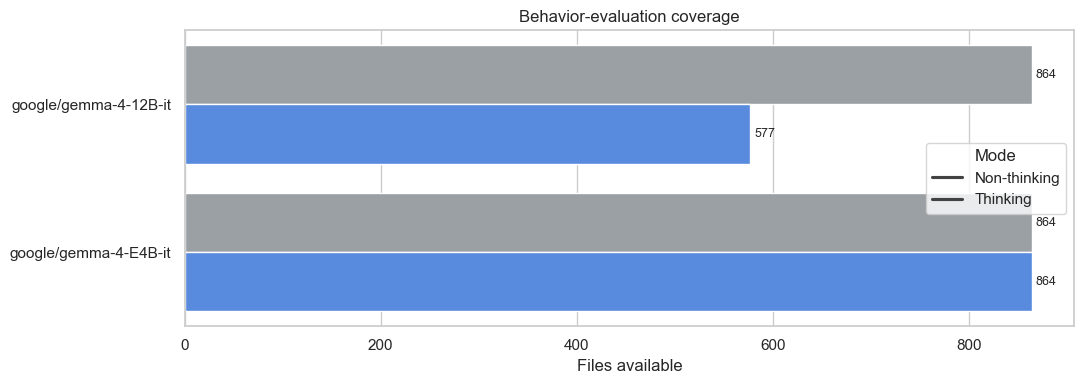

In [11]:
coverage = (
    raw_df.groupby(["model", "mode", "status"], observed=True)
    .size().rename("count").reset_index()
)
coverage_total = (
    coverage.groupby(["model", "mode"], observed=True)["count"]
    .sum().reset_index()
)

fig, ax = plt.subplots(figsize=(11, max(4, 0.9 * coverage_total["model"].nunique())))
sns.barplot(
    data=coverage_total,
    y="model", x="count", hue="mode",
    hue_order=MODE_ORDER, palette=["#9aa0a6", "#4285f4"], ax=ax,
)
ax.set(title="Behavior-evaluation coverage", xlabel="Files available", ylabel="")
ax.legend(title="Mode", labels=[MODE_LABELS[m] for m in MODE_ORDER])
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

## Overall behavior distribution

These rates use every successfully evaluated row currently available. For a model still running, treat the chart as provisional and use the paired analysis below for a fair comparison.

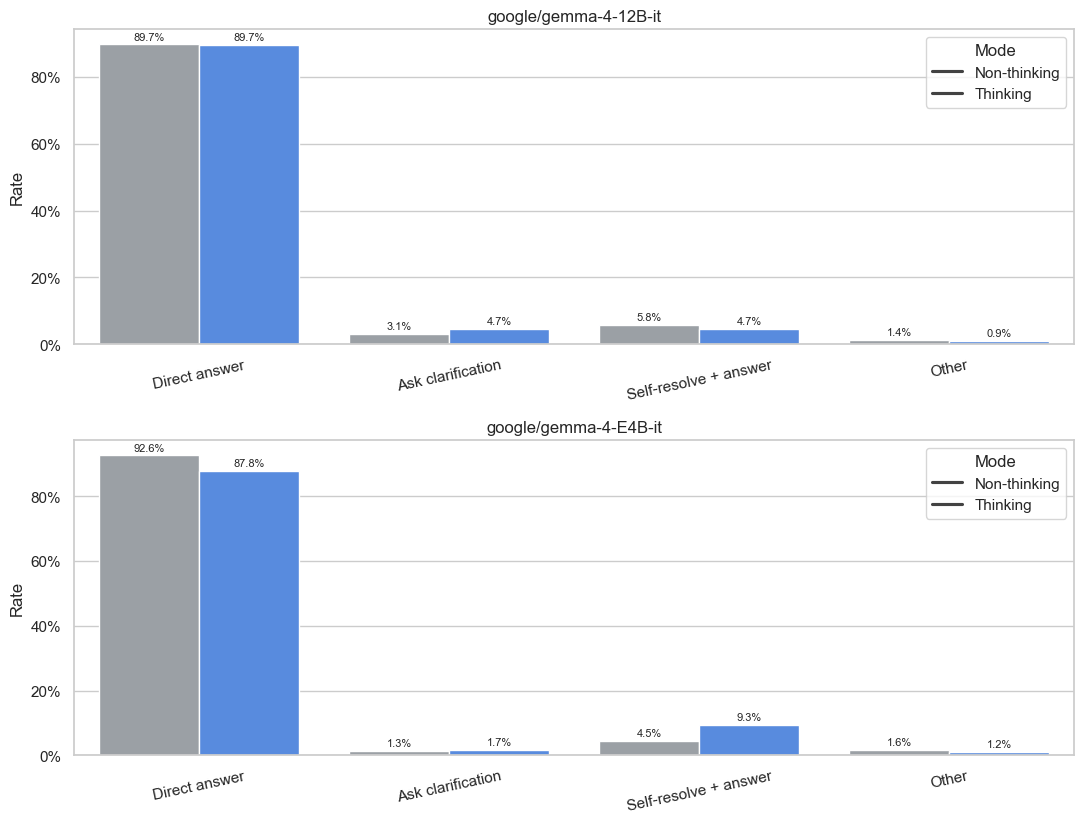

,model,mode,label,count,total,rate,behavior
0,google/gemma-4-12B-it,non_thinking,1,775,864,0.896991,Direct answer
1,google/gemma-4-12B-it,non_thinking,2,27,864,0.031250,Ask clarification
2,google/gemma-4-12B-it,non_thinking,3,50,864,0.057870,Self-resolve + answer
3,google/gemma-4-12B-it,non_thinking,4,12,864,0.013889,Other
4,google/gemma-4-12B-it,thinking,1,191,213,0.896714,Direct answer
5,google/gemma-4-12B-it,thinking,2,10,213,0.046948,Ask clarification
6,google/gemma-4-12B-it,thinking,3,10,213,0.046948,Self-resolve + answer
7,google/gemma-4-12B-it,thinking,4,2,213,0.009390,Other
8,google/gemma-4-E4B-it,non_thinking,1,800,864,0.925926,Direct answer
9,google/gemma-4-E4B-it,non_thinking,2,11,864,0.012731,Ask clarification


In [12]:
labels = [1, 2, 3, 4]
models = sorted(evaluated_df["model"].unique())
overall_counts = (
    evaluated_df.groupby(["model", "mode", "label"], observed=True)
    .size().rename("count").reset_index()
)
totals = (
    evaluated_df.groupby(["model", "mode"], observed=True)
    .size().rename("total").reset_index()
)
overall = overall_counts.merge(totals, on=["model", "mode"])
overall["rate"] = overall["count"] / overall["total"]
overall["behavior"] = overall["label"].map(LABEL_NAMES)

fig, axes = plt.subplots(
    len(models), 1,
    figsize=(11, max(4.5, 4.2 * len(models))),
    squeeze=False,
)
for ax, model in zip(axes.flat, models):
    subset = overall.loc[overall["model"].eq(model)]
    sns.barplot(
        data=subset, x="behavior", y="rate", hue="mode",
        order=[LABEL_NAMES[x] for x in labels], hue_order=MODE_ORDER,
        palette=["#9aa0a6", "#4285f4"], ax=ax,
    )
    ax.set(title=model, xlabel="", ylabel="Rate")
    ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
    ax.tick_params(axis="x", rotation=12)
    ax.legend(title="Mode", labels=[MODE_LABELS[m] for m in MODE_ORDER])
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v.get_height():.1%}" for v in container], padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_overall_behavior_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

display(overall.sort_values(["model", "mode", "label"]))

## Strict paired comparison

The following cells retain only samples with both modes. This automatically gives the 12B model a valid partial comparison while it is running, and a full comparison after it finishes.

In [13]:
index_cols = ["model", "conflict_type_idx", "sample_id"]
paired = (
    evaluated_df.pivot_table(index=index_cols, columns="mode", values="label", aggfunc="first")
    .dropna(subset=MODE_ORDER)
    .reset_index()
)
paired[MODE_ORDER] = paired[MODE_ORDER].astype(int)

def exact_mcnemar_p(gain, loss):
    discordant = gain + loss
    if discordant == 0:
        return 1.0
    smaller = min(gain, loss)
    return min(1.0, 2 * sum(comb(discordant, k) for k in range(smaller + 1)) / (2 ** discordant))

comparison_rows = []
for model, group in paired.groupby("model", observed=True):
    for label, outcome in [
        (2, "Ask clarification (L2)"),
        (3, "Self-resolve + answer (L3)"),
        ((2, 3), "Acknowledges conflict (L2+L3)"),
    ]:
        target = {label} if isinstance(label, int) else set(label)
        non = group["non_thinking"].isin(target)
        think = group["thinking"].isin(target)
        gain = int((~non & think).sum())
        loss = int((non & ~think).sum())
        comparison_rows.append({
            "model": model,
            "outcome": outcome,
            "paired_n": len(group),
            "non_thinking_rate": non.mean(),
            "thinking_rate": think.mean(),
            "difference_pp": 100 * (think.mean() - non.mean()),
            "gain": gain,
            "loss": loss,
            "exact_mcnemar_p": exact_mcnemar_p(gain, loss),
        })

paired_summary = pd.DataFrame(comparison_rows)
display(
    paired_summary.style.format({
        "non_thinking_rate": "{:.2%}",
        "thinking_rate": "{:.2%}",
        "difference_pp": "{:+.2f}",
        "exact_mcnemar_p": "{:.4g}",
    })
)
paired_summary.to_csv(FIGURE_DIR / "paired_behavior_summary.csv", index=False)

,model,outcome,paired_n,non_thinking_rate,thinking_rate,difference_pp,gain,loss,exact_mcnemar_p
0,google/gemma-4-12B-it,Ask clarification (L2),213,1.88%,4.69%,+2.82,7,1,0.07031
1,google/gemma-4-12B-it,Self-resolve + answer (L3),213,4.69%,4.69%,+0.00,6,6,1
2,google/gemma-4-12B-it,Acknowledges conflict (L2+L3),213,6.57%,9.39%,+2.82,12,6,0.2379
3,google/gemma-4-E4B-it,Ask clarification (L2),862,1.28%,1.74%,+0.46,13,9,0.5235
4,google/gemma-4-E4B-it,Self-resolve + answer (L3),862,4.52%,9.28%,+4.76,58,17,2.182e-06
5,google/gemma-4-E4B-it,Acknowledges conflict (L2+L3),862,5.80%,11.02%,+5.22,66,21,1.41e-06


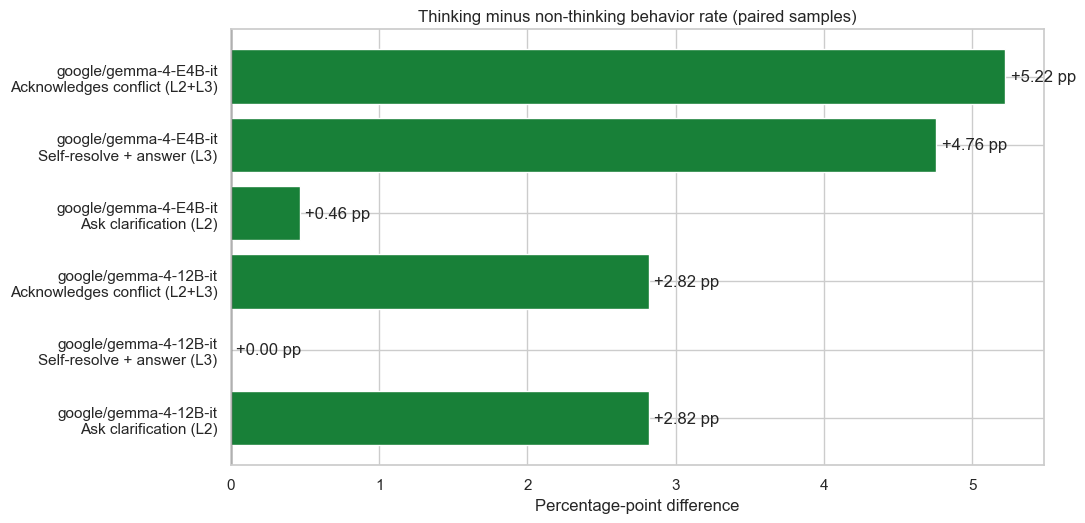

In [14]:
fig, ax = plt.subplots(figsize=(11, max(4.5, 0.9 * len(paired_summary))))
plot_data = paired_summary.copy()
plot_data["model_outcome"] = plot_data["model"] + "\n" + plot_data["outcome"]
colors = ["#d93025" if value < 0 else "#188038" for value in plot_data["difference_pp"]]
bars = ax.barh(plot_data["model_outcome"], plot_data["difference_pp"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set(
    title="Thinking minus non-thinking behavior rate (paired samples)",
    xlabel="Percentage-point difference",
    ylabel="",
)
ax.bar_label(bars, labels=[f"{x:+.2f} pp" for x in plot_data["difference_pp"]], padding=4)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_paired_rate_differences.png", dpi=200, bbox_inches="tight")
plt.show()

## Behavior by conflict type

Label 2 and Label 3 are shown separately because thinking may change *how* the model handles a recognized conflict: asking the user versus resolving the conflict itself.

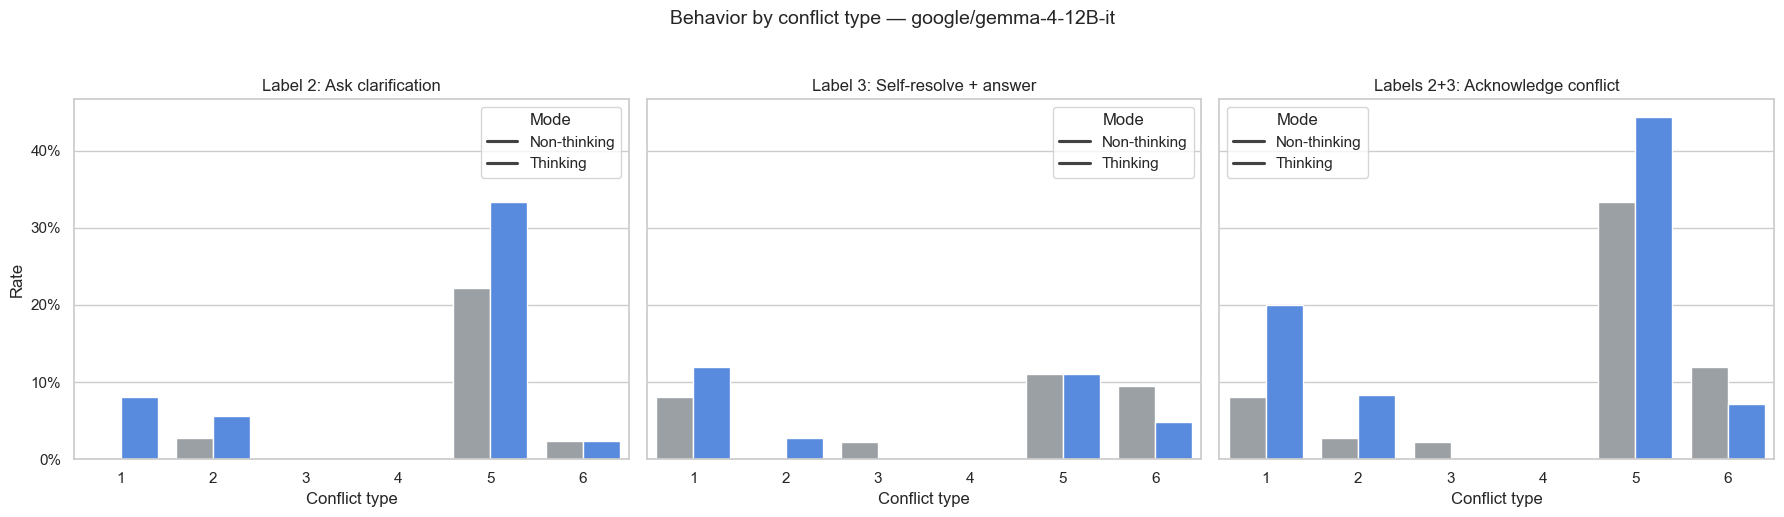

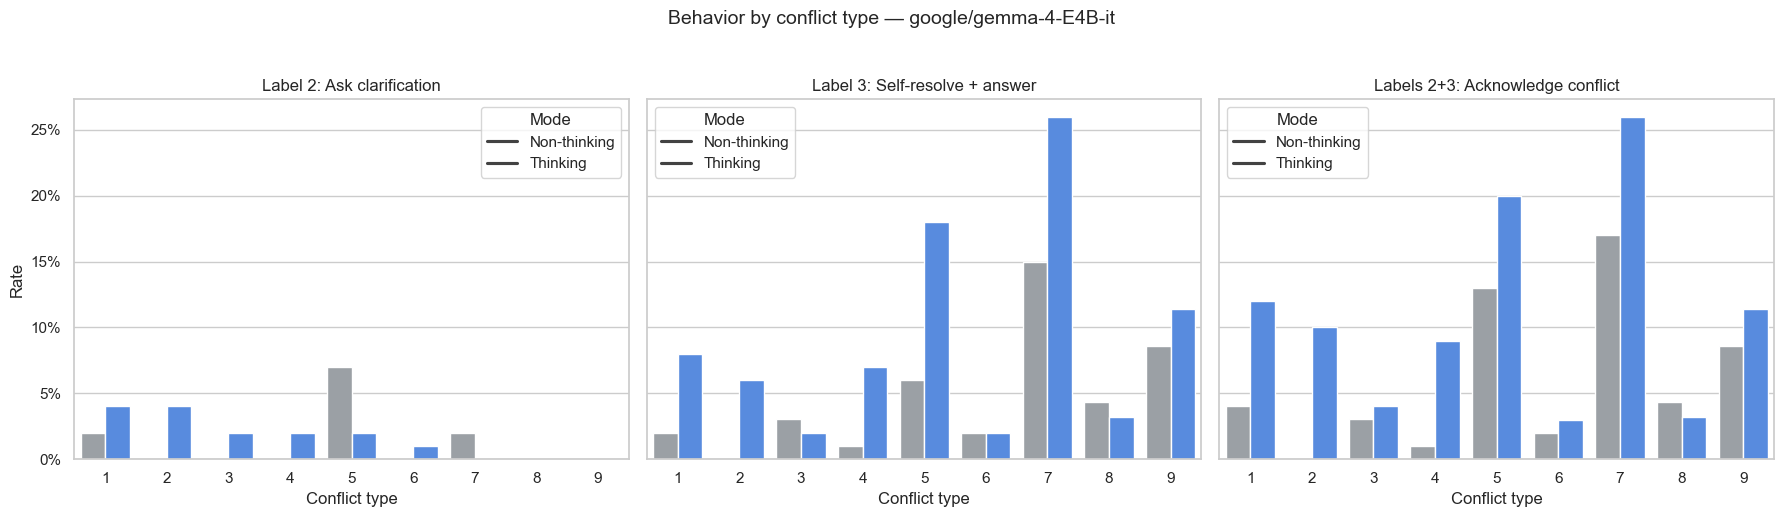

In [15]:
type_rows = []
for (model, conflict_type), group in paired.groupby(["model", "conflict_type_idx"], observed=True):
    for mode in MODE_ORDER:
        for outcome, target in [
            ("Label 2: Ask clarification", {2}),
            ("Label 3: Self-resolve + answer", {3}),
            ("Labels 2+3: Acknowledge conflict", {2, 3}),
        ]:
            type_rows.append({
                "model": model,
                "conflict_type_idx": conflict_type,
                "mode": mode,
                "outcome": outcome,
                "paired_n": len(group),
                "rate": group[mode].isin(target).mean(),
            })
type_rates = pd.DataFrame(type_rows)

for model in sorted(type_rates["model"].unique()):
    subset = type_rates.loc[type_rates["model"].eq(model)]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, outcome in zip(axes, subset["outcome"].drop_duplicates()):
        panel = subset.loc[subset["outcome"].eq(outcome)]
        sns.barplot(
            data=panel, x="conflict_type_idx", y="rate", hue="mode",
            hue_order=MODE_ORDER, palette=["#9aa0a6", "#4285f4"], ax=ax,
        )
        ax.set(title=outcome, xlabel="Conflict type", ylabel="Rate")
        ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
        ax.legend(title="Mode", labels=[MODE_LABELS[m] for m in MODE_ORDER])
    fig.suptitle(f"Behavior by conflict type — {model}", y=1.03, fontsize=14)
    plt.tight_layout()
    safe_model = model.replace("/", "__")
    plt.savefig(FIGURE_DIR / f"04_by_conflict_type__{safe_model}.png", dpi=200, bbox_inches="tight")
    plt.show()

## Paired transition matrices

Rows are non-thinking labels and columns are thinking labels. Off-diagonal cells show behavior changes caused by switching the same checkpoint/input pair into thinking mode.

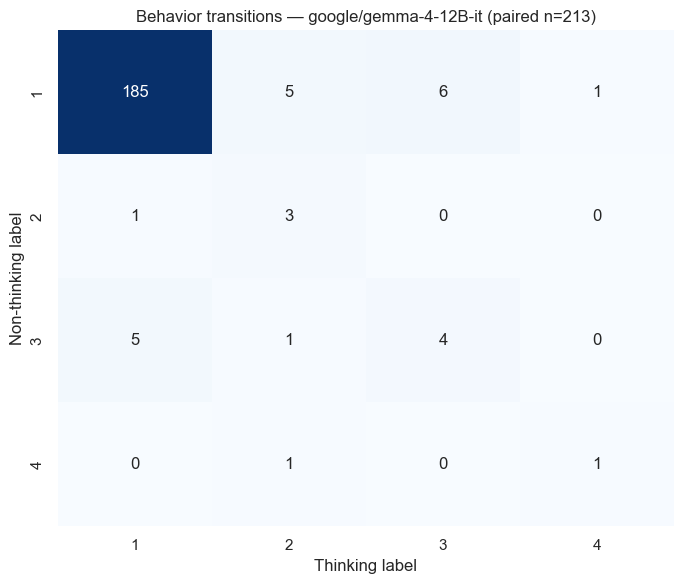

thinking,1,2,3,4
non_thinking,,,,
1,185,5,6,1
2,1,3,0,0
3,5,1,4,0
4,0,1,0,1


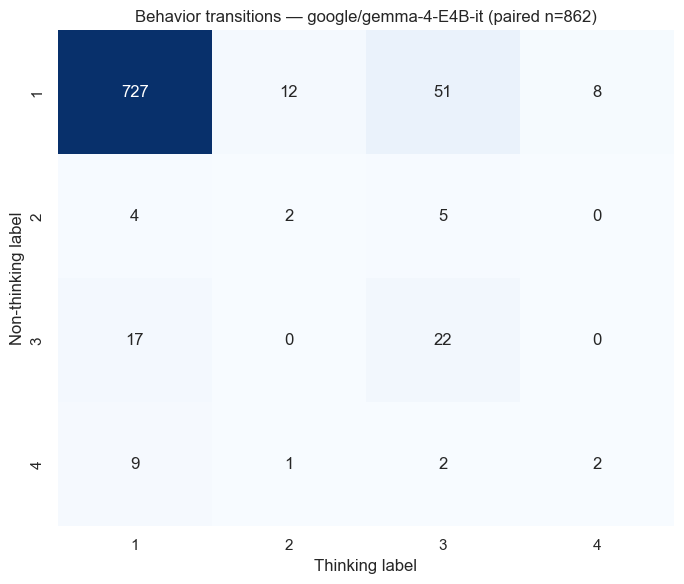

thinking,1,2,3,4
non_thinking,,,,
1,727,12,51,8
2,4,2,5,0
3,17,0,22,0
4,9,1,2,2


In [16]:
for model, group in paired.groupby("model", observed=True):
    matrix = pd.crosstab(group["non_thinking"], group["thinking"])
    matrix = matrix.reindex(index=[1, 2, 3, 4], columns=[1, 2, 3, 4], fill_value=0)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set(
        title=f"Behavior transitions — {model} (paired n={len(group):,})",
        xlabel="Thinking label",
        ylabel="Non-thinking label",
    )
    plt.tight_layout()
    safe_model = model.replace("/", "__")
    plt.savefig(FIGURE_DIR / f"05_transition_matrix__{safe_model}.png", dpi=200, bbox_inches="tight")
    plt.show()
    display(matrix)

## Interpretation checklist

- Use the coverage chart before interpreting an unfinished model.
- Prefer paired results for thinking/non-thinking causal comparisons.
- Report Label 2 and Label 3 separately; their combined rate measures conflict acknowledgement, but they represent different downstream behaviors.
- Inspect parse failures before treating missing thinking rows as random.
- The labels are produced by `gpt-4o-2024-11-20`; validate a stratified sample manually before treating them as ground truth.